# Stage 3 — Flow Matching as a Layer Before Linear Probe

This notebook implements continuous/discrete **Conditional Flow Matching (CFM)** as a vector field layer $v_\theta(z_t, t)$ inserted **BEFORE** the linear probe classifier ($s = W \tilde{z} + b$).

---
### Architectural Flow:
$$\text{Cached Image Features } z_0 \longrightarrow \text{Flow Matching ODE Integration } (t: 0 \to 1) \longrightarrow \tilde{z} \longrightarrow \text{Linear Probe } (W \tilde{z} + b) \longrightarrow \text{Logits}$$
---


## 1. Setup & Environment


In [1]:
%matplotlib inline
import matplotlib
try:
    matplotlib.use("module://matplotlib_inline.backend_inline")
except Exception:
    pass


import os
import sys
import logging
import warnings
from pathlib import Path

# Suppress noisy library warnings
warnings.filterwarnings("ignore")
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("matplotlib").setLevel(logging.ERROR)

import torch

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    if not os.path.exists("/content/flow-matching-as-a-layer"):
        !git clone https://github.com/Asaf21S/flow-matching-as-a-layer.git
    %cd /content/flow-matching-as-a-layer
    !git pull --ff-only
    !pip install -q -r requirements-colab.txt

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

DATA_ROOT = REPO_ROOT / "data"
FEATURE_ROOT = REPO_ROOT / "features"
RESULTS_ROOT = REPO_ROOT / "results"

for path in (DATA_ROOT, FEATURE_ROOT, RESULTS_ROOT):
    path.mkdir(parents=True, exist_ok=True)

os.environ["FMLAYER_DATA_ROOT"] = str(DATA_ROOT)
os.environ["FMLAYER_FEATURE_ROOT"] = str(FEATURE_ROOT)
os.environ["FMLAYER_RESULTS_ROOT"] = str(RESULTS_ROOT)

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Environment: {'Colab' if IN_COLAB else 'Local'}")
print(f"PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}")

Environment: Local
PyTorch: 2.13.0+cu130 | CUDA: True


## 2. Dataset Preparation & Feature Cache Verification


In [2]:
from src.fmlayer.data.prepare import prepare_datasets
from src.fmlayer.features.extract import extract_all
from src.fmlayer.data.fewshot import build_all_subsets

# Ensure datasets are downloaded and cached features are ready
dataset_report = prepare_datasets()
feature_report = extract_all()
subsets = build_all_subsets()
print("Datasets, feature caches, and subset indices ready.")

Data root: /home/ordinary/projects/flow-matching-as-a-layer/or/stage3/data

=== FGVC-Aircraft (aircraft) ===
    protocol: {'annotation_level': 'variant'}, approx. 2750 MB
    [ok] train   3334 images, 100 classes, 33-34 per class
    [ok] val     3333 images, 100 classes, 33-34 per class
    [ok] test    3333 images, 100 classes, 33-34 per class
    prompt: 'a photo of a 707-320 aircraft' ... 'a photo of a Yak-42 aircraft'
=== DTD (dtd) ===
    protocol: {'partition': 1}, approx. 625 MB
    [ok] train   1880 images, 47 classes, 40-40 per class
    [ok] val     1880 images, 47 classes, 40-40 per class
    [ok] test    1880 images, 47 classes, 40-40 per class
    prompt: 'a photo of a banded texture' ... 'a photo of a zigzagged texture'
Device: cuda

=== resnet18 ===
    [cached] resnet18/dtd/train -> dtd_train.npz
    [cached] resnet18/dtd/val -> dtd_val.npz
    [cached] resnet18/dtd/test -> dtd_test.npz
    [cached] resnet18/aircraft/train -> aircraft_train.npz
    [cached] resnet18/a

Using cache found in /home/ordinary/.cache/torch/hub/facebookresearch_dinov2_main


    [cached] dinov2_vits14/dtd/train -> dtd_train.npz
    [cached] dinov2_vits14/dtd/val -> dtd_val.npz
    [cached] dinov2_vits14/dtd/test -> dtd_test.npz

=== clip_rn50 ===


    [cached] clip_rn50/dtd/train -> dtd_train.npz
    [cached] clip_rn50/dtd/val -> dtd_val.npz
    [cached] clip_rn50/dtd/test -> dtd_test.npz
    [cached] clip_rn50/dtd/text -> dtd_text.npz
    [cached] clip_rn50/aircraft/train -> aircraft_train.npz
    [cached] clip_rn50/aircraft/val -> aircraft_val.npz
    [cached] clip_rn50/aircraft/test -> aircraft_test.npz
    [cached] clip_rn50/aircraft/text -> aircraft_text.npz

17 feature files ready.

=== dtd (1880 training images, 47 classes) ===
    k=5    seed=0    235 images, 5-5 per class
    k=5    seed=1    235 images, 5-5 per class
    k=5    seed=2    235 images, 5-5 per class
    k=10   seed=0    470 images, 10-10 per class
    k=10   seed=1    470 images, 10-10 per class
    k=10   seed=2    470 images, 10-10 per class
    k=full seed=0   1880 images, 40-40 per class

=== aircraft (3334 training images, 100 classes) ===
    k=5    seed=0    500 images, 5-5 per class
    k=5    seed=1    500 images, 5-5 per class
    k=5    seed=2 

## 3. Flow Matching Layer & Composite Model Smoke Test


In [3]:
import torch
from src.fmlayer.encoders.base import default_device
from src.fmlayer.models.flow_matching import VectorFieldMLP, FlowMatchingLayer, compute_cfm_loss, build_flow_matching_layer
from src.fmlayer.models.stage3 import Stage3, build_stage3

device = default_device()
# Test vector field, CFM loss, and integration on synthetic features
dummy_x = torch.randn(16, 512, device=device)
fm_probe = build_stage3(embed_dim=512, num_classes=47, seed=42, device=device)
dummy_logits = fm_probe(dummy_x, num_steps=10)

print(f"Flow Matching Layer + Linear Probe instantiated successfully!")
print(f"Input shape: {dummy_x.shape} -> Output logits shape: {dummy_logits.shape}")

Flow Matching Layer + Linear Probe instantiated successfully!
Input shape: torch.Size([16, 512]) -> Output logits shape: torch.Size([16, 47])


## 4. Flow Matching Layer + Linear Probe Training Grid


In [4]:
from src.fmlayer.train.train_fm import run_all_stage3
from src.fmlayer.train.train_linear import summarize_linear_probes

# Train Flow Matching vector field + linear probe across 3 encoders x K in {5, 10, full} x 3 seeds
fm_results = run_all_stage3(max_epochs=200, cfm_epochs=50)
fm_summary = summarize_linear_probes(fm_results)

Device: cuda


fm linear probes:   4%|▎         | 1/27 [00:06<02:40,  6.17s/it]

    [FM Layer] resnet18       dtd       k=5    seed=0  train=  235  val=0.4324@13   test=0.4516


fm linear probes:   7%|▋         | 2/27 [00:12<02:32,  6.08s/it]

    [FM Layer] resnet18       dtd       k=5    seed=1  train=  235  val=0.4468@12   test=0.4484


...

    [FM Layer] dinov2_vits14  dtd       k=full seed=0  train= 1880  val=0.7707@7    test=0.7543


fm linear probes:  96%|█████████▋| 26/27 [10:43<00:29, 29.28s/it]

    [FM Layer] dinov2_vits14  dtd       k=full seed=1  train= 1880  val=0.7633@7    test=0.7670


fm linear probes: 100%|██████████| 27/27 [11:26<00:00, 25.41s/it]

    [FM Layer] dinov2_vits14  dtd       k=full seed=2  train= 1880  val=0.7681@14   test=0.7681

27 FM linear-probe runs complete.
dinov2_vits14/dtd/10           0.6874 +/- 0.0059  (n=3)
dinov2_vits14/dtd/5            0.6177 +/- 0.0028  (n=3)
dinov2_vits14/dtd/full         0.7631 +/- 0.0063  (n=3)
resnet18/aircraft/10           0.2458 +/- 0.0048  (n=3)
resnet18/aircraft/5            0.1739 +/- 0.0052  (n=3)
resnet18/aircraft/full         0.3648 +/- 0.0034  (n=3)
resnet18/dtd/10                0.5232 +/- 0.0044  (n=3)
resnet18/dtd/5                 0.4470 +/- 0.0045  (n=3)
resnet18/dtd/full              0.6035 +/- 0.0085  (n=3)


## 5. Deliverables & Baseline Comparison



=== FGVC-Aircraft ===
  clip_zeroshot  clip_rn50      K=none  0.1554 +/- 0.0000  (n=1)
  fm_linear_probe resnet18       K=5     0.1739 +/- 0.0064  (n=3)
  fm_linear_probe resnet18       K=10    0.2458 +/- 0.0059  (n=3)
  fm_linear_probe resnet18       K=full  0.3648 +/- 0.0042  (n=3)
  linear_probe   resnet18       K=5     0.1974 +/- 0.0153  (n=3)
  linear_probe   resnet18       K=10    0.2725 +/- 0.0062  (n=3)
  linear_probe   resnet18       K=full  0.3654 +/- 0.0012  (n=3)
  stage3         resnet18       K=5     0.1739 +/- 0.0064  (n=3)
  stage3         resnet18       K=10    0.2458 +/- 0.0059  (n=3)
  stage3         resnet18       K=full  0.3648 +/- 0.0042  (n=3)

=== DTD ===
  clip_zeroshot  clip_rn50      K=none  0.4005 +/- 0.0000  (n=1)
  fm_linear_probe dinov2_vits14  K=5     0.6177 +/- 0.0034  (n=3)
  fm_linear_probe dinov2_vits14  K=10    0.6874 +/- 0.0073  (n=3)
  fm_linear_probe dinov2_vits14  K=full  0.7631 +/- 0.0077  (n=3)
  fm_linear_probe resnet18       K=5     0.4470 

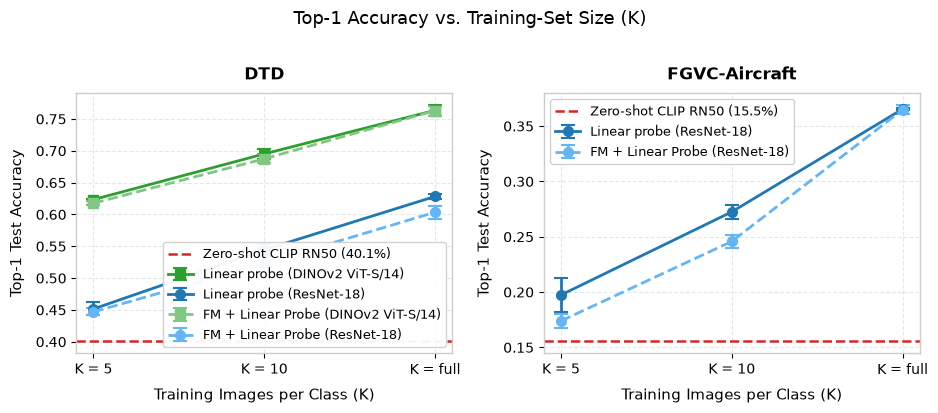

In [5]:
from src.fmlayer.report import accuracy_table, print_accuracy_table
from src.fmlayer.viz.accuracy import plot_combined_accuracy_vs_k

table = accuracy_table()
print_accuracy_table(table)
plot_combined_accuracy_vs_k(table)

## 6. Flow Matching Layer Visualizations

In Continuous Normalizing Flows and Flow Matching literature (Lipman et al., 2022), visualizing vector fields $v_\theta(z_t, t)$ and ODE trajectories $z_0 \to z_1$ provides insight into how representations are refined across the continuous trajectory.


### 6.1 2D Vector Field Streamline Plot ($v_\theta(z_t, t)$)


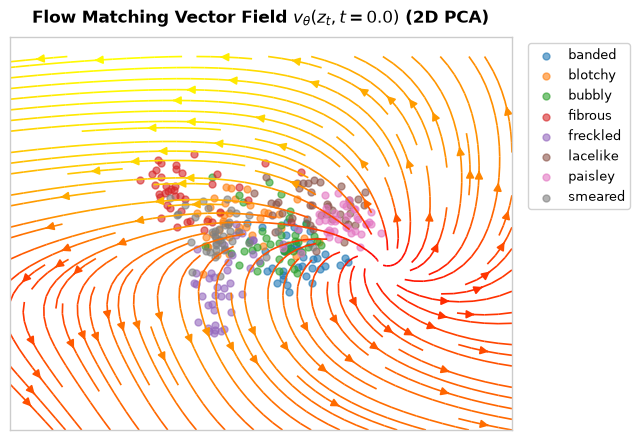

In [6]:
from src.fmlayer.features.cache import load_split
from src.fmlayer.viz.flow_viz import plot_flow_vector_field_2d, plot_flow_trajectories_2d, plot_before_after_embeddings

# Select a representative trained model and test split
target_key = "resnet18/dtd/full/0"
sample_model = fm_results[target_key]["model"] if "fm_results" in locals() and target_key in fm_results else fm_probe
test_feats, test_lbls, test_meta = load_split("resnet18", "dtd", "test")

# Plot continuous vector field streamlines over 2D PCA projection
plot_flow_vector_field_2d(sample_model, test_feats, test_lbls, test_meta, t=0.0, device=device)

### 6.2 ODE Sample Flow Trajectories ($z_0 \rightarrow z_1$)


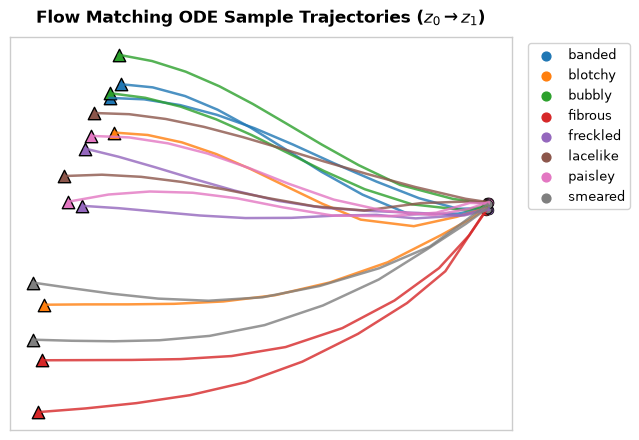

In [7]:
# Plot integration flow trajectories from z0 to z1 across 2D PCA representation space
plot_flow_trajectories_2d(sample_model, test_feats, test_lbls, test_meta, num_steps=10, device=device)

### 6.3 Before vs. After Feature Representation Scatter Comparison


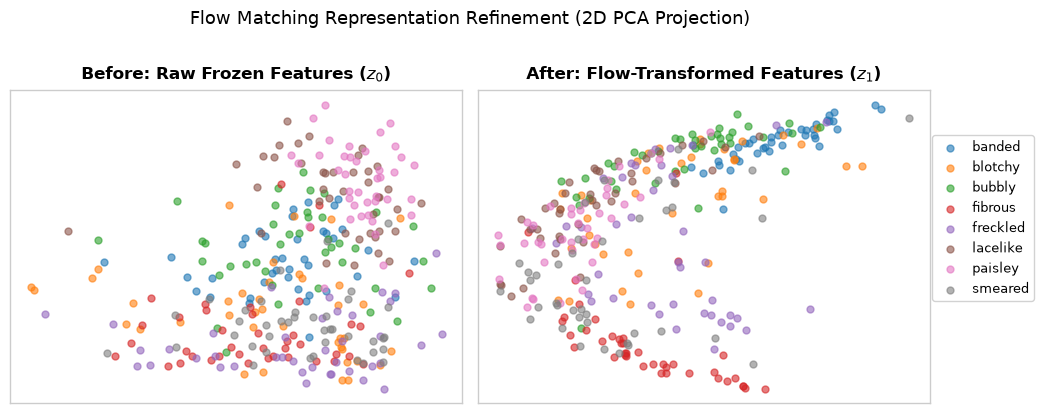

In [8]:
# Side-by-side 2D PCA comparison of raw frozen features vs. flow-transformed features
plot_before_after_embeddings(sample_model, test_feats, test_lbls, test_meta, device=device)